In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pickle


In [23]:
FILENAME = 'scan_data_1780588864.6213105.pkl'

data = {}
with open('../data/' + FILENAME, 'rb') as f:
    data = pickle.load(f)


In [24]:
print(np.array(data['scans']['scans'][0]))
print(data['scans']['metadata'])


[29.985762 30.012638 29.991293 ... 29.998644 29.98893  30.012783]
{'angle_min': -2.3499999046325684, 'angle_max': 2.3499999046325684, 'angle_increment': 0.004351851996034384, 'range_min': 0.0, 'range_max': 30.0}


In [25]:
def cartesian_to_xy(scan, scan_metadata, max_dist=29.9):
    
    num_points = len(scan)
    xy_points = np.zeros((num_points, 2))
    
    curr_angle = scan_metadata['angle_min']
    angle_increment = scan_metadata['angle_increment']
    
    # print(scan)
    
    for idx, distance in enumerate(scan):
        
        x, y = np.inf, np.inf
        # print(distance)
        if distance <= max_dist:
            x = distance * np.cos(curr_angle)
            y = distance * np.sin(curr_angle)
        
        xy_points[idx, :] = [x, y]
        
        curr_angle += angle_increment
        
    return xy_points
        
def batch_process_point_clouds(scans, scan_metadata):
    
    num_scans = len(scans)
    num_points = len(scans[0])
    
    parsed_scans = np.zeros((num_scans, num_points, 2))
    
    for idx, scan in enumerate(scans):
        parsed_scans[idx, :, :] = cartesian_to_xy(scan, scan_metadata)

    return parsed_scans


In [26]:
parsed_scans = batch_process_point_clouds(data['scans']['scans'], data['scans']['metadata'])


In [52]:
from scipy.interpolate import interp1d
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import time
# from cv2 import minAreaRect

class OrientedBoundingBox:
    
    def __init__(self, centroid_x_m, centroid_y_m, length_m, width_m, heading_rad):
        self.centroid_x_m = centroid_x_m
        self.centroid_y_m = centroid_y_m
        self.length_m = length_m
        self.width_m = width_m
        self.heading_rad = heading_rad

class OccupancyGrid2D:
    
    def __init__(self, point_cloud, grid_size_m=0.05):
        
        self.point_cloud = point_cloud
        self.grid_size_m = grid_size_m
        
        # initialize occupancy grid array
        self.grid, self.x_idx_offset, self.y_idx_offset = self.initialize_grid(grid_size_m=grid_size_m)
        
        # fill grid with points
        self.fill_grid()

    def initialize_grid(self, grid_size_m=0.05):
        
        x_min, x_max = np.min(self.point_cloud[:, 0]), np.max(self.point_cloud[:, 0])
        y_min, y_max = np.min(self.point_cloud[:, 1]), np.max(self.point_cloud[:, 1])
        
        num_x_buckets = int(x_max // grid_size_m) - int(x_min // grid_size_m) + 1
        num_y_buckets = int(y_max // grid_size_m) - int(y_min // grid_size_m) + 1
        
        x_idx_offset = -1 * int(x_min // grid_size_m)
        y_idx_offset = -1 * int(y_min // grid_size_m)
        
        return np.zeros((num_x_buckets, num_y_buckets)), x_idx_offset, y_idx_offset
    
    def fill_grid(self):
        
        for point in self.point_cloud:
            x_idx = int(point[0] // self.grid_size_m) + self.x_idx_offset
            y_idx = int(point[1] // self.grid_size_m) + self.y_idx_offset
            self.grid[x_idx, y_idx] += 1
            
    def get_spaces_with_at_least_n_points(self, min_points):
        
        filtered_point_cloud = []
        
        for x_idx in range(self.grid.shape[0]):
            for y_idx in range(self.grid.shape[1]):
                if self.grid[x_idx][y_idx] >= min_points:
                    x_mean = (x_idx - self.x_idx_offset + 0.5) * self.grid_size_m
                    y_mean = (y_idx - self.y_idx_offset + 0.5) * self.grid_size_m
                    filtered_point_cloud.append([x_mean, y_mean])
                    
        return np.array(filtered_point_cloud)

class SlamManager:
        
    def __init__(self, scan_data, odom_data):
        
        start_time = time.perf_counter()
        
        self.scan_data = scan_data
        self.odom_data = odom_data
        
        self.scans = self.scan_data['scans']
        self.scan_metadata = self.scan_data['metadata']
        self.scan_times = self.scan_data['times']
        
        self.pose_array = np.array(self.odom_data['poses'])
        self.initial_ego_pose = self.pose_array[0,:] # [x, y, theta]
        
        # create linear interpolators for time to pose functions
        self.time_to_global_x = interp1d(self.odom_data['times'], self.pose_array[:,0], fill_value="extrapolate")
        self.time_to_global_y = interp1d(self.odom_data['times'], self.pose_array[:,1], fill_value="extrapolate")
        self.time_to_global_theta = interp1d(self.odom_data['times'], self.pose_array[:,2], fill_value="extrapolate")
        
        self.time_to_local_x = lambda time, x: x + (self.time_to_global_x(time) - self.initial_ego_pose[0])
        self.time_to_local_y = lambda time, y: y + (self.time_to_global_y(time) - self.initial_ego_pose[1])
        self.time_to_local_theta = lambda time, theta: theta + (self.time_to_global_theta(time) - self.initial_ego_pose[2])
        
        print(f"Setup time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        # do all the lidar preprocessing here
        self.parsed_scans = self.batch_process_point_clouds()
        print(f"Batch proc time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        self.aligned_point_clouds = self.align_point_clouds()
        print(f"Align time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        self.filtered_point_cloud = self.filter_finite_points(self.aligned_point_clouds)
        print(f"Filter time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        self.downsampled_point_cloud = self.downsample_point_cloud(self.filtered_point_cloud)
        print(f"Downsample time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        # cluster aligned point clouds
        self.cluster_idxs = self.cluster_points(self.downsampled_point_cloud)
        print(f"Cluster time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
        
        # extract bounding boxes from individual clusters
        self.bounding_boxes = self.extract_obbs(self.downsampled_point_cloud, self.cluster_idxs)
        print(f"OBB extraction time: {time.perf_counter() - start_time:.6f} seconds"); start_time = time.perf_counter()
    
    def cartesian_to_xy(self, scan, scan_metadata, max_dist=29.9):
    
        num_points = len(scan)
        xy_points = np.zeros((num_points, 2))
        
        curr_angle = scan_metadata['angle_min']
        angle_increment = scan_metadata['angle_increment']
        
        # print(scan)
    
        for idx, distance in enumerate(scan):
            
            x, y = np.inf, np.inf
            # print(distance)
            if distance <= max_dist:
                x = distance * np.cos(curr_angle)
                y = distance * np.sin(curr_angle)
            
            xy_points[idx, :] = [x, y]
            
            curr_angle += angle_increment
            
            return xy_points
        
    def batch_process_point_clouds(self):
        
        num_scans = len(self.scans)
        num_points = len(self.scans[0])
        
        parsed_scans = np.zeros((num_scans, num_points, 2))
        
        for idx, scan in enumerate(self.scans):
            parsed_scans[idx, :, :] = cartesian_to_xy(scan, self.scan_metadata)

        return parsed_scans
    
    def align_point_clouds(self):
        
        num_scans = len(self.parsed_scans)
        num_points = len(self.parsed_scans[0])
        
        aligned_point_clouds = np.zeros((num_scans * num_points, 2))
        
        for scan_idx, scan in enumerate(self.parsed_scans):
            scan_time = self.scan_times[scan_idx]
            points_x = self.time_to_local_x(scan_time, scan[:, 0])
            points_y = self.time_to_local_y(scan_time, scan[:, 1])
            
            lower_idx = scan_idx * num_points
            upper_idx = (scan_idx + 1) * num_points
            aligned_point_clouds[lower_idx:upper_idx, 0] = points_x
            aligned_point_clouds[lower_idx:upper_idx, 1] = points_y
            
        return aligned_point_clouds
    
    def filter_finite_points(self, point_cloud):
        mask = np.isfinite(point_cloud)
        filtered_point_cloud = point_cloud[mask].reshape(-1, 2)
        return filtered_point_cloud
    
    def downsample_point_cloud(self, point_cloud, grid_size_m=0.02, min_samples=3):
        
        grid = OccupancyGrid2D(point_cloud, grid_size_m)
        return grid.get_spaces_with_at_least_n_points(min_samples)
    
    def cluster_points(self, point_cloud, min_cluster_size=5):
        
        clustering = HDBSCAN(min_cluster_size=min_cluster_size).fit(point_cloud)
        return clustering.labels_
        
    def extract_obbs(self, point_cloud, cluster_idxs):
        
        num_clusters = np.max(cluster_idxs) + 1
        
        for idx in range(num_clusters):
            cluster_points = point_cloud[cluster_idxs == idx]
            self.obb_from_cluster_points(cluster_points)
            
    def obb_from_cluster_points(self, cluster_points):
        
        # perform pca to get the heading of the bounding box
        
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(cluster_points)
        
        pca = PCA(n_components=2)
        pca.fit(scaled_data)

        pc1 = pca.components_[0]
        angle_rad = np.arctan2(pc1[1], pc1[0])
        angle_deg = np.degrees(angle_rad)
        
        print(angle_deg)



In [53]:
s = SlamManager(data['scans'], data['poses'])


Setup time: 0.001467 seconds
Batch proc time: 1.024344 seconds
Align time: 0.090017 seconds
Filter time: 0.005506 seconds
Downsample time: 0.203247 seconds
Cluster time: 0.003473 seconds
-45.00000000000015
-134.9999999999987
OBB extraction time: 0.001133 seconds


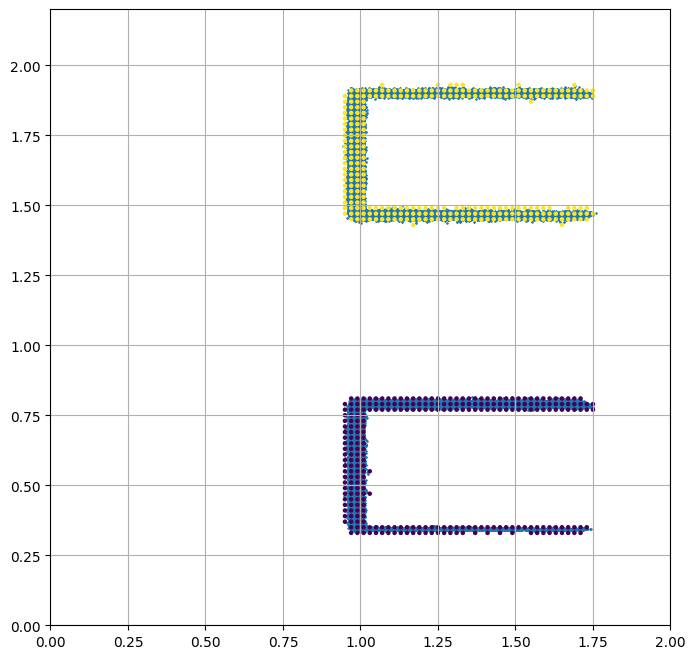

In [33]:
plt.scatter(-s.aligned_point_clouds[:,1], s.aligned_point_clouds[:,0], s=0.3)
plt.scatter(-s.downsampled_point_cloud[:,1], s.downsampled_point_cloud[:,0], s=5.0, c=s.cluster_idxs)
plt.ylim(0, 2.2)
plt.xlim(0, 2)
plt.gcf().set_size_inches(8, 8)
plt.grid()


In [30]:
mask = np.isfinite(s.aligned_point_clouds)
point_cloud = s.aligned_point_clouds[mask].reshape(-1, 2)

np.min(point_cloud[:,1])


-1.7586455405380066

In [ ]:
np.max(s.cluster_idxs)


1